# Confidence intervals — MKID (TiN), heavy mediator (F_DM = 1), m_DM = 1 GeV

Point-wise profile confidence bands of the recovered flux x(v_min), one
subsection per halo model. Method and conventions:
[`quantum_sensor.statistics.find_confidence_band`](../src/quantum_sensor/statistics.py)
(neutrinoAnalysis construction: observed profile Δχ² vs an MC-calibrated
cutoff; Poisson pseudo-experiments; CLARABEL solver, thread-parallel).

- Configuration: `material='TiN', q='0', mass='3', nbins=5`, background `none`
- Outputs per model: `results/MKID/bkg-none/<config>/` —
  `band/band_idx*.json` (primary, one per point), `flux_profile_band.csv`
  (summary), `flux_profile_band.pdf` (figure)
- **Each `run_model` cell takes ~30–60 min** (production MC settings).
  Already computed? Use `show_saved` in §Saved results instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sensor import (DarkMatterQuantumAnalysis, RunConfig,
                            pointwise_band, load_pointwise_band,
                            band_table, save_band_products)
from quantum_sensor.plotting import plot_flux_with_pointwise_bands, run_dir

MATERIAL, Q, MASS, NBINS = 'TiN', '0', '3', 5
LEVELS = (0.68, 0.954)                                   # 1 sigma, 2 sigma
MC = dict(num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)  # production settings
N_INDICES = 30


def build(eta='Halo', disk_fraction=None):
    cfg = RunConfig(material=MATERIAL, q=Q, mass=MASS, nbins=NBINS,
                    eta=eta, disk_fraction=disk_fraction, background='none')
    a = DarkMatterQuantumAnalysis(cfg)
    a.optimize()
    return a


def run_model(eta='Halo', disk_fraction=None):
    """Compute, save and display the band for one halo model (heavy)."""
    a = build(eta, disk_fraction)
    print(f'{a.config}')
    print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
    bands = pointwise_band(a, n_indices=N_INDICES, levels=LEVELS, **MC)
    save_band_products(a, bands)
    display(band_table(bands))
    return a, bands


def show_saved(eta='Halo', disk_fraction=None):
    """Reload a saved band (band/*.json) — no recomputation."""
    a = build(eta, disk_fraction)
    bands = load_pointwise_band(run_dir(a))
    print(f'{len(bands)} points from {run_dir(a) / "band"}')
    display(band_table(bands))
    plot_flux_with_pointwise_bands(a, bands, save=False)
    return a, bands


## 1. Standard halo (SHM)


RunConfig(material='TiN', q='0', mass='3', nbins=5, eta='Halo', disk_fraction=None, background='none', run=None)
counts per bin: [12.8 38.8 57.2 74.5 90.3]
[1/25] idx 0 (v=5 km/s)  best 4.18e-28 cm^-1  1sigma [3.76e-28, 1.79e-22]  2sigma [3.53e-28, 4.65e-22]  (60 evals)
[2/25] idx 1 (v=6 km/s)  best 4.18e-28 cm^-1  1sigma [3.81e-28, 3.45e-24]  2sigma [3.57e-28, 8.58e-24]  (49 evals)
[3/25] idx 2 (v=7 km/s)  best 4.18e-28 cm^-1  1sigma [3.81e-28, 8.16e-25]  2sigma [3.57e-28, 2.04e-24]  (45 evals)
[4/25] idx 3 (v=8 km/s)  best 4.18e-28 cm^-1  1sigma [3.81e-28, 3.31e-25]  2sigma [3.53e-28, 8.93e-25]  (44 evals)
[5/25] idx 4 (v=9 km/s)  best 4.18e-28 cm^-1  1sigma [3.81e-28, 2.08e-25]  2sigma [3.53e-28, 4.75e-25]  (42 evals)
[6/25] idx 5 (v=9 km/s)  best 4.18e-28 cm^-1  1sigma [3.81e-28, 1.16e-25]  2sigma [3.48e-28, 2.77e-25]  (42 evals)
[7/25] idx 6 (v=10 km/s)  best 4.18e-28 cm^-1  1sigma [3.81e-28, 8.03e-26]  2sigma [3.48e-28, 1.76e-25]  (40 evals)
[8/25] idx 8 (v=12 km/s)  best 4.18e-2

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,5.4,4.184292e-28,3.757132e-28,1.787177e-22,3.526486e-28,4.650085e-22,-10%,+42711479%,60
1,1,6.2,4.184292e-28,3.805040e-28,3.452439e-24,3.571454e-28,8.583088e-24,-9%,+824995%,49
2,2,7.0,4.184292e-28,3.805040e-28,8.156100e-25,3.571454e-28,2.035728e-24,-9%,+194822%,45
3,3,7.8,4.184292e-28,3.805040e-28,3.309372e-25,3.526486e-28,8.933704e-25,-9%,+78990%,44
4,4,8.6,4.184292e-28,3.805040e-28,2.078196e-25,3.526486e-28,4.750590e-25,-9%,+49567%,42
5,5,9.4,4.184292e-28,3.805040e-28,1.155214e-25,3.482085e-28,2.771425e-25,-9%,+27508%,42
6,6,10.2,4.184292e-28,3.805040e-28,8.025153e-26,3.482085e-28,1.757690e-25,-9%,+19079%,40
7,8,11.8,4.184292e-28,3.805040e-28,3.592231e-26,3.526486e-28,7.695258e-26,-9%,+8485%,38
8,9,12.6,4.184292e-28,3.805040e-28,2.330351e-26,3.526486e-28,5.177272e-26,-9%,+5469%,33
9,12,15.0,4.184292e-28,3.805040e-28,5.405864e-27,3.526486e-28,1.201005e-26,-9%,+1192%,33


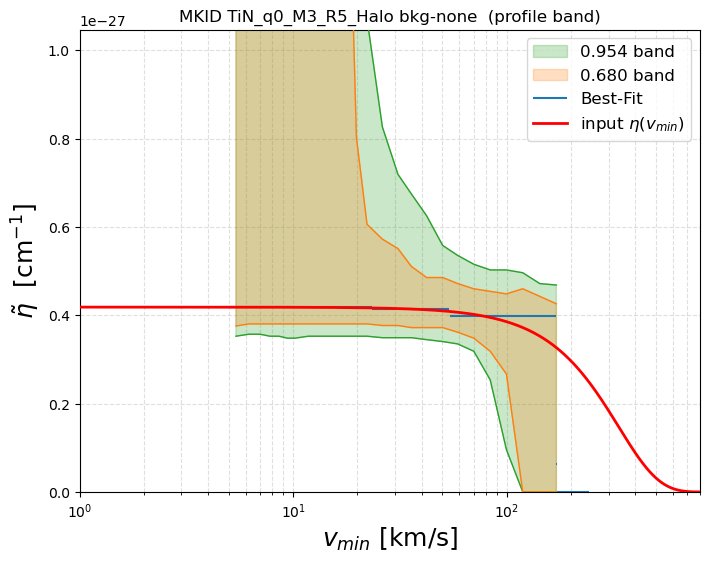

In [2]:
a_halo, b_halo = run_model(eta='Halo')


## 2. Pure dark disk


In [ ]:
a_disk, b_disk = run_model(eta='Disk')


## 3. Halo + dark-disk mixtures

The fit eta is `(1-p)·Halo + p·Disk` with the same total local DM density.


RunConfig(material='TiN', q='0', mass='3', nbins=5, eta='Halo', disk_fraction=0.05, background='none', run=None)
counts per bin: [13.9 41.8 60.9 78.1 93.1]
[1/25] idx 0 (v=5 km/s)  best 4.53e-28 cm^-1  1sigma [4.02e-28, 1.61e-22]  2sigma [3.72e-28, 4.37e-22]  (58 evals)
[2/25] idx 1 (v=6 km/s)  best 4.53e-28 cm^-1  1sigma [4.12e-28, 3.07e-24]  2sigma [3.72e-28, 8.42e-24]  (50 evals)
[3/25] idx 2 (v=7 km/s)  best 4.53e-28 cm^-1  1sigma [4.12e-28, 7.78e-25]  2sigma [3.72e-28, 2.06e-24]  (46 evals)
[4/25] idx 3 (v=8 km/s)  best 4.53e-28 cm^-1  1sigma [4.07e-28, 3.92e-25]  2sigma [3.72e-28, 9.53e-25]  (42 evals)
[5/25] idx 4 (v=9 km/s)  best 4.53e-28 cm^-1  1sigma [4.07e-28, 2.16e-25]  2sigma [3.72e-28, 4.93e-25]  (41 evals)
[6/25] idx 5 (v=9 km/s)  best 4.53e-28 cm^-1  1sigma [4.07e-28, 1.3e-25]  2sigma [3.72e-28, 2.92e-25]  (35 evals)
[7/25] idx 6 (v=10 km/s)  best 4.53e-28 cm^-1  1sigma [4.07e-28, 8.76e-26]  2sigma [3.72e-28, 2e-25]  (35 evals)
[8/25] idx 7 (v=11 km/s)  best 4.53e-28 cm

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,5.4,4.530376e-28,4.016668e-28,1.613102e-22,3.722621e-28,4.368412e-22,-11%,+35606256%,58
1,1,6.2,4.530376e-28,4.119757e-28,3.066594e-24,3.722621e-28,8.417146e-24,-9%,+676796%,50
2,2,7.0,4.530376e-28,4.119757e-28,7.776709e-25,3.722621e-28,2.063077e-24,-9%,+171557%,46
3,3,7.8,4.530376e-28,4.067886e-28,3.921622e-25,3.722621e-28,9.528165e-25,-10%,+86463%,42
4,4,8.6,4.530376e-28,4.067886e-28,2.155890e-25,3.722621e-28,4.928193e-25,-10%,+47487%,41
5,5,9.4,4.530376e-28,4.067886e-28,1.297676e-25,3.722621e-28,2.919772e-25,-10%,+28544%,35
6,6,10.2,4.530376e-28,4.067886e-28,8.761489e-26,3.722621e-28,1.996472e-25,-10%,+19239%,35
7,7,11.0,4.530376e-28,4.067886e-28,5.920132e-26,3.722621e-28,1.258204e-25,-10%,+12968%,37
8,9,12.6,4.530376e-28,4.067886e-28,2.620850e-26,3.722621e-28,5.822666e-26,-10%,+5685%,32
9,11,14.2,4.530376e-28,4.067886e-28,1.084676e-26,3.722621e-28,2.212257e-26,-10%,+2294%,31


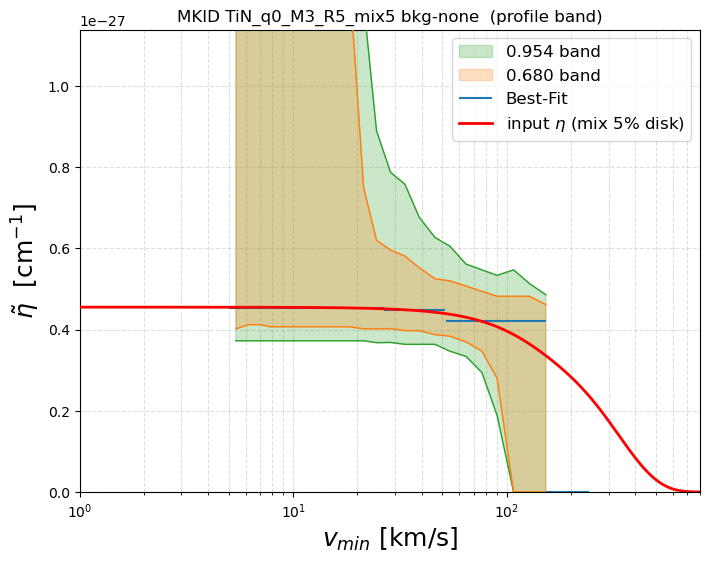

In [2]:
a_mix5, b_mix5 = run_model(disk_fraction=0.05)    # 5% disk


In [ ]:
a_mix25, b_mix25 = run_model(disk_fraction=0.25)  # 25% disk


## 4. Earth-bound population (Halo + Bound)

The bound population sits on top of the full SHM halo; it is nonzero only
below v_esc = 11.2 km/s, which only the 1 GeV window reaches.


In [ ]:
a_bound, b_bound = run_model(eta='Bound')


RunConfig(material='TiN', q='0', mass='3', nbins=5, eta='Bound', disk_fraction=None, background='none', run=None)
counts per bin: [6.6e+09 9.7e+07 3.2e+04 8.4e+01 9.0e+01]
[1/25] idx 0 (v=5 km/s)  best 3.85e-15 cm^-1  1sigma [3.83e-15, 3.88e-15]  2sigma [3.83e-15, 3.88e-15]  (13 evals)
[2/25] idx 1 (v=6 km/s)  best 3.85e-15 cm^-1  1sigma [3.83e-15, 3.88e-15]  2sigma [3.83e-15, 3.88e-15]  (13 evals)
[3/25] idx 2 (v=7 km/s)  best 8.48e-16 cm^-1  1sigma [8.42e-16, 8.53e-16]  2sigma [8.42e-16, 8.53e-16]  (13 evals)
[4/25] idx 3 (v=8 km/s)  best 3.69e-20 cm^-1  1sigma [3.67e-20, 3.71e-20]  2sigma [3.67e-20, 3.71e-20]  (13 evals)
[5/25] idx 4 (v=9 km/s)  best 3.69e-20 cm^-1  1sigma [3.67e-20, 3.71e-20]  2sigma [3.67e-20, 3.71e-20]  (13 evals)
[6/25] idx 6 (v=10 km/s)  best 2.65e-20 cm^-1  1sigma [2.64e-20, 2.67e-20]  2sigma [2.64e-20, 2.67e-20]  (13 evals)
[7/25] idx 7 (v=11 km/s)  best 3.83e-28 cm^-1  1sigma [3.8e-28, 3.85e-28]  2sigma [3.8e-28, 3.85e-28]  (13 evals)
[8/25] idx 9 (v=13 km/s

## Saved results (no recomputation)

Reload any model computed above (or in a previous session).


In [ ]:
show_saved(eta='Halo');
# show_saved(eta='Disk');
# show_saved(disk_fraction=0.05);
# show_saved(disk_fraction=0.25);
# show_saved(eta='Bound');
